2026-05-04 13:11:22.168782: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-04 13:11:22.168956: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-04 13:11:22.168965: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-04 13:11:22.169248: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 13:11:22.169259: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Target layer: conv5_block16_2_conv


/Users/divydadheech/Documents/Academics/SDP3/SDP/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


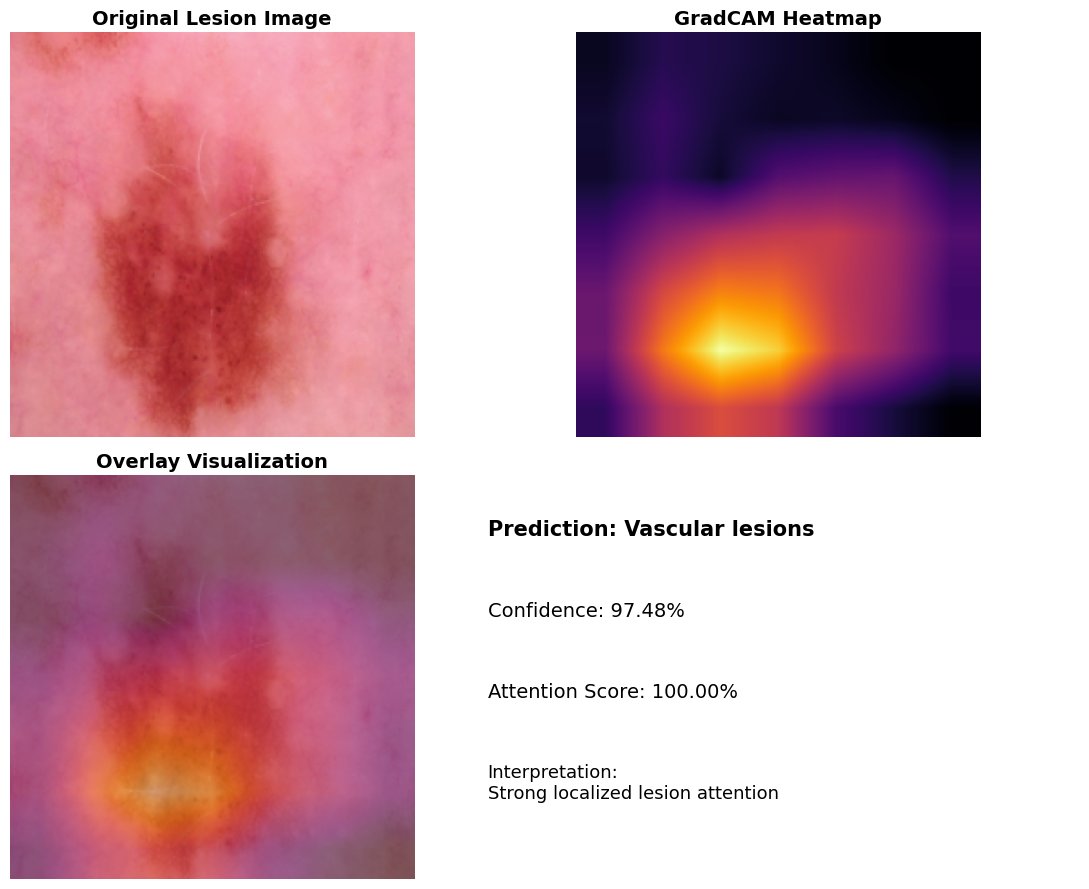

Saved: Figure_4_3_GradCAM_Examples.png


In [1]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# ==========================
# SETTINGS
# ==========================
IMAGE_PATH = "sample_lesion.jpg"
MODEL_PATH = "../backend/skin_disease_model_v2.keras"

CLASSES = [
    "Melanocytic nevi",
    "Melanoma",
    "Benign keratosis",
    "Basal cell carcinoma",
    "Actinic keratoses",
    "Vascular lesions",
    "Dermatofibroma",
]

IMG_SIZE = (224, 224)

# ==========================
# LOAD MODEL
# ==========================
model = tf.keras.models.load_model(MODEL_PATH)

# ==========================
# PREPROCESS
# ==========================
img_pil = Image.open(IMAGE_PATH).convert("RGB")
original = img_pil.resize(IMG_SIZE)

img = np.array(original) / 255.0
img = np.expand_dims(img, axis=0)

# ==========================
# FIND LAST CONV
# ==========================
target_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        target_layer = layer.name
        break

print("Target layer:", target_layer)

# ==========================
# GRADCAM
# ==========================
grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(target_layer).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img)
    class_idx = tf.argmax(predictions[0])
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

guided_grads = (
    tf.cast(conv_outputs > 0, "float32")
    * tf.cast(grads > 0, "float32")
    * grads
)

weights = tf.reduce_mean(guided_grads, axis=(0, 1, 2))
cam = tf.reduce_sum(weights * conv_outputs[0], axis=-1)

cam = tf.nn.relu(cam)
cam = cam / (tf.reduce_max(cam) + 1e-8)
cam = cam.numpy()

# ==========================
# HEATMAP
# ==========================
heatmap = cv2.resize(cam, IMG_SIZE)
heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_INFERNO
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# overlay
original_np = np.array(original)
overlay = (
    0.55 * original_np
    + 0.45 * heatmap_color
).astype(np.uint8)

# prediction info
preds = predictions.numpy()[0]
idx = int(np.argmax(preds))
confidence = preds[idx] * 100
attention_score = float(np.max(cam) * 100)

# ==========================
# PLOT
# ==========================
fig, ax = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

ax[0,0].imshow(original_np)
ax[0,0].set_title(
    "Original Lesion Image",
    fontsize=14,
    fontweight="bold"
)

ax[0,1].imshow(heatmap_color)
ax[0,1].set_title(
    "GradCAM Heatmap",
    fontsize=14,
    fontweight="bold"
)

ax[1,0].imshow(overlay)
ax[1,0].set_title(
    "Overlay Visualization",
    fontsize=14,
    fontweight="bold"
)

ax[1,1].axis("off")
ax[1,1].text(
    0.02,
    0.85,
    f"Prediction: {CLASSES[idx]}",
    fontsize=15,
    fontweight="bold"
)

ax[1,1].text(
    0.02,
    0.65,
    f"Confidence: {confidence:.2f}%",
    fontsize=14
)

ax[1,1].text(
    0.02,
    0.45,
    f"Attention Score: {attention_score:.2f}%",
    fontsize=14
)

ax[1,1].text(
    0.02,
    0.20,
    "Interpretation:\nStrong localized lesion attention",
    fontsize=13
)

for row in ax:
    for a in row:
        a.axis("off")

plt.tight_layout()

plt.savefig(
    "Figure_4_3_GradCAM_Examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Figure_4_3_GradCAM_Examples.png")